In [1]:
import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import binomtest

In [2]:
UNARY_MODELS = [
    'DeepSet', 
    'PointNet',
    'NormDeepSet',
    'HPDS',
    'QUANN-1'
]

BINARY_MODELS = [
    'SetTransformer', 
    'QUANN-2'
]

MODELS = {
    'Unary' : UNARY_MODELS,
    'Binary' : BINARY_MODELS,
}

In [3]:
def round_latex_numbers(df, decimals=3):
    def round_cell(val):
        if isinstance(val, str):
            # Match numbers inside possible \textbf{...}
            match = re.match(r'(\\textbf\{)?([-+]?[0-9]*\.?[0-9]+)(\})?', val)
            if match:
                prefix = match.group(1) or ''
                number = float(match.group(2))
                suffix = match.group(3) or ''
                return f"{prefix}{number:.{decimals}f}{suffix}"
            return val  # leave other strings untouched
        elif isinstance(val, (int, float)):
            return f"{val:.{decimals}f}"
        else:
            return str(val)  # just to be safe

    return df.applymap(round_cell)

In [4]:
def highlight_significant(df, maximize=True):
    """
    Return a new DataFrame with LaTeX bold applied to significantly better cells.

    Parameters:
    - df: pandas DataFrame with 'mean ± std' strings
    - maximize: True if higher values are better, False if lower is better

    Returns:
    - DataFrame of strings with \textbf{} wrapping applied
    """
    result = df.copy()

    for idx, row in df.iterrows():
        stats = {col: parse_mean_std(row[col]) for col in df.columns}

        for model_i in df.columns:
            mean_i, std_i = stats[model_i]
            better_than_all = True

            for model_j in df.columns:
                if model_i == model_j:
                    continue
                mean_j, std_j = stats[model_j]
                diff = mean_i - mean_j if maximize else mean_j - mean_i
                margin = std_i + std_j

                if diff <= margin:
                    better_than_all = False
                    break

            if better_than_all:
                # Apply LaTeX bold
                result.loc[idx, model_i] = f"\\textbf{{{df.loc[idx, model_i]}}}"

    return result

In [5]:
def highlight_significant_latex(df, maximize=True):
    """
    Highlights the model in each row with significantly better performance 
    using LaTeX \\textbf{...} around the 'mean' value.

    A model is significantly better if its mean differs from every other model's
    mean by more than the sum of the stds.

    Parameters:
    - df: DataFrame with MultiIndex columns (Model, Metric)
    - maximize: bool, True if higher is better, False if lower is better

    Returns:
    - DataFrame with LaTeX \\textbf{} applied where significant
    """
    highlighted_df = df.copy()

    models = df.columns.get_level_values(0).unique()
    metric_names = df.columns.get_level_values(1).unique()
    
    assert 'Mean' in metric_names and 'Std' in metric_names, "Expected 'Mean' and 'Std' as second-level column labels."

    for idx, row in df.iterrows():
        means = {model: row[(model, 'Mean')] for model in models}
        stds = {model: row[(model, 'Std')] for model in models}

        for candidate in models:
            better_than_all = True
            for other in models:
                if candidate == other:
                    continue

                diff = means[candidate] - means[other]
                margin = stds[candidate] + stds[other]

                if maximize:
                    if diff <= margin:
                        better_than_all = False
                        break
                else:
                    if -diff <= margin:  # i.e., means[candidate] >= means[other] - margin
                        better_than_all = False
                        break

            if better_than_all:
                mean_val = highlighted_df.loc[idx, (candidate, 'Mean')]
                highlighted_df.loc[idx, (candidate, 'Mean')] = f"\\textbf{{{mean_val}}}"
                break  # only one model should be bolded per row

    return highlighted_df

In [6]:
# Initialize container of results for win-loss matrices
results_summary = {}

<br>

## Synthetic data experiment

<br>

### Comparison with ablation models

In [7]:
RES_PATH = './results/Synthetic_experiment/'
NUM_REPLICATES = 10

In [8]:
synthetic_experiment_results = []
for i in range(NUM_REPLICATES):
    fn = os.path.join(RES_PATH, 'replicate_{}.csv'.format(i))
    r = pd.read_csv(fn, index_col = 0)
    r.insert(0, 'Replicate', i)
    synthetic_experiment_results.append(r)

synthetic_experiment_results = pd.concat(synthetic_experiment_results, axis = 0)

In [9]:
model_map = {
    'Ablation_1' : 'Ablation 1', 
    'Ablation_2' : 'Ablation 2', 
    'QUANN_1' : 'QUANN-1'
}

funcs_map = {
    'geometric_median' : 'Geometric median', 
    'P2_mean' : 'Quadratic mean', 
    'marginal_median' : 'Median',
    'L2_medoid' : 'Medoid',
    'midpoint' : 'Midpoint',
    'norm_max' : 'VecMaxNorm',
    'row_max' : 'Max',
    'log_sum_exp' : 'LogSumExp',
    'variance' : 'Variance',
    'skewness': 'Skewness'
}

test_loss_table = (
    synthetic_experiment_results
    .groupby(['Model', 'Aggregator', 'Learning rate', 'Parameters'])[['Eval loss 10','Test loss']]
    .agg(
        {
            'Eval loss 10': ['mean', 'std'],
            'Test loss': ['mean', 'std']
        }
    )
    .pipe(lambda df_: df_.set_axis(['Eval mean', 'Eval std', 'Test mean', 'Test std'], axis=1))
    .reset_index()
    .sort_values('Eval mean')
    .drop_duplicates(subset = ['Model', 'Aggregator'])
    .rename(columns = {'Test mean' : 'Mean', 'Test std' : 'Std'})
    .replace({
        'Model' : model_map,
        'Aggregator' : funcs_map
    })
)

In [10]:
# Pivot the table
funcs = ['Geometric median', 'Quadratic mean', 'Median', 'Medoid', 'Midpoint', 'VecMaxNorm', 'Max', 'LogSumExp', 'Variance', 'Skewness']
models = ['Ablation 1', 'Ablation 2', 'QUANN-1']
test_loss_table = test_loss_table.pivot(index='Aggregator', columns="Model", values=['Mean', 'Std']).swaplevel(axis=1).sort_index(axis=1).loc[funcs,models]

# Remove column/index names
test_loss_table.columns.names = [None, None]
test_loss_table.index.name = None

In [11]:
# Highlihgt significant values
test_loss_table = highlight_significant_latex(test_loss_table, maximize=False)

# Reduce decimals to three
test_loss_table = round_latex_numbers(test_loss_table)

In [12]:
latex_table = test_loss_table.to_latex(
    multicolumn=True,
    multicolumn_format='r',
    multirow=True,
    bold_rows=False,
    column_format='l' + 'r' * (test_loss_table.shape[1]),  # left align first column
    escape=False,  # so that \textbf{} is preserved
)

# Boldify column headers
latex_table = re.sub(r'\\multicolumn\{2\}\{[clr]\}\{(.*?)\}', r'\\multicolumn{2}{c}{\\textbf{\1}}', latex_table)

# Add cmidrules
lines = latex_table.splitlines()
lines.insert(3, '\cmidrule(r){2-3} \cmidrule(r){4-5} \cmidrule(r){6-7}')
latex_table = '\n'.join(lines)

In [13]:
with open('./results/synthetic_experiment.tex', 'w') as f:
    f.write(latex_table)

<br>

### RevNet vs RealNVP coupling analysis (supplementary result)

In [14]:
RES_PATH = './results/Synthetic_experiment_3/'
NUM_REPLICATES = 5

In [15]:
synthetic_experiment_results_3 = []
for i in range(NUM_REPLICATES):
    fn = os.path.join(RES_PATH, 'replicate_{}.csv'.format(i))
    r = pd.read_csv(fn, index_col = 0)
    r.insert(0, 'Replicate', i)
    synthetic_experiment_results_3.append(r)

synthetic_experiment_results_3 = pd.concat(synthetic_experiment_results_3, axis = 0)

In [16]:
model_map = {
    'QUANN' : 'QUANN-RevNet', 
    'QUANN_NVP' : 'QUANN-RealNVP',
}

funcs_map = {
    'geometric_median' : 'Geometric median', 
    'P2_mean' : 'Quadratic mean', 
    'marginal_median' : 'Median',
    'L2_medoid' : 'Medoid',
    'midpoint' : 'Midpoint',
    'norm_max' : 'VecMaxNorm',
    'row_max' : 'Max',
    'log_sum_exp' : 'LogSumExp',
    'variance' : 'Variance',
    'skewness': 'Skewness'
}

test_loss_table = (
    synthetic_experiment_results_3
    .groupby(['Model', 'Aggregator', 'Learning rate', 'Parameters'])[['Eval loss 10','Test loss']]
    .agg(
        {
            'Eval loss 10': ['mean', 'std'],
            'Test loss': ['mean', 'std']
        }
    )
    .pipe(lambda df_: df_.set_axis(['Eval mean', 'Eval std', 'Test mean', 'Test std'], axis=1))
    .reset_index()
    .sort_values('Eval mean')
    .drop_duplicates(subset = ['Model', 'Aggregator'])
    .rename(columns = {'Test mean' : 'Mean', 'Test std' : 'Std'})
    .replace({
        'Model' : model_map,
        'Aggregator' : funcs_map
    })
)

In [17]:
# Pivot the table
funcs = ['Geometric median', 'Quadratic mean', 'Median', 'Medoid', 'Midpoint', 'VecMaxNorm', 'Max', 'LogSumExp', 'Variance', 'Skewness']
models = ['QUANN-RevNet', 'QUANN-RealNVP']
test_loss_table = test_loss_table.pivot(index='Aggregator', columns="Model", values=['Mean', 'Std']).swaplevel(axis=1).sort_index(axis=1).loc[funcs,models]

# Remove column/index names
test_loss_table.columns.names = [None, None]
test_loss_table.index.name = None

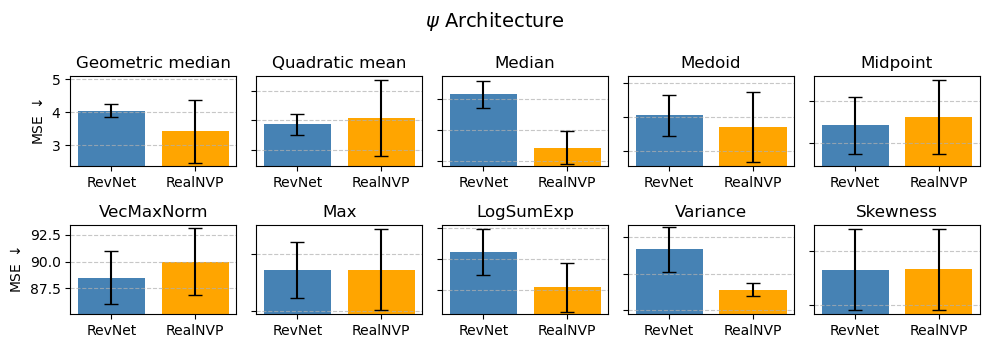

In [18]:
fig, axes = plt.subplots(2, 5, figsize=(10, 3.5))
axes = axes.flatten()

models = ['QUANN-RevNet', 'QUANN-RealNVP']
xtick_labels = ['RevNet', 'RealNVP']
colors = ['steelblue', 'orange']

# Loop over each row in the table (each aggregation function)
for i, (index, row) in enumerate(test_loss_table.iterrows()):
    means = [row[(model, 'Mean')] for model in models]
    stds = [row[(model, 'Std')] for model in models]
    
    ax = axes[i]
    ax.bar(xtick_labels, means, yerr=stds, capsize=5, color=colors)
    ax.set_title(str(index))
    # ax.set_ylim(bottom=0)
    ax.set_ylim([min(means) - max(stds) * 1.1, max(means) + max(stds) * 1.1])
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Show y-axis label only for leftmost column (i % 5 == 0)
    if i % 5 == 0:
        ax.set_ylabel(r'MSE $\downarrow$')
    else:
        ax.set_ylabel('')
        ax.set_yticklabels([])

plt.suptitle(r'$\psi$ Architecture', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 1.00])
plt.savefig('./results/synthetic_experiment_3.png', dpi = 500, bbox_inches='tight')
plt.show()

<br>

### QUANN performance analysis (supplementary result)

In [19]:
RES_PATH = './results/Synthetic_experiment_2/'
NUM_REPLICATES = 5

In [20]:
characteristic = {
    'QUANN_1' : [1, '[32]'],
    'QUANN_2' : [2, '[32]'],
    'QUANN_3' : [4, '[32]'],
    'QUANN_1a' : [1, '[32, 32]'],
    'QUANN_2a' : [2, '[32, 32]'],
    'QUANN_3a' : [4, '[32, 32]'],
    'QUANN_1c' : [1, '[64]'],
    'QUANN_2c' : [2, '[64]'],
    'QUANN_3c' : [4, '[64]'],
}

characteristic = pd.DataFrame.from_dict(characteristic, orient = 'index', columns = ['Num. blocks', 'Hidden layers'])

In [21]:
synthetic_experiment_2_results = []
for i in range(NUM_REPLICATES):
    fn = os.path.join(RES_PATH, 'replicate_{}.csv'.format(i))
    r = pd.read_csv(fn, index_col = 0)
    r.insert(0, 'Replicate', i)
    synthetic_experiment_2_results.append(r)

synthetic_experiment_2_results = pd.concat(synthetic_experiment_2_results, axis = 0)

In [22]:
model_map = {
    'Ablation_1' : 'Ablation 1', 
    'Ablation_2' : 'Ablation 2', 
    'QUANN_1' : 'QUANN-1'
}

funcs_map = {
    'geometric_median' : 'Geometric median', 
    'P2_mean' : 'Quadratic mean', 
    'marginal_median' : 'Median',
    'L2_medoid' : 'Medoid',
    'midpoint' : 'Midpoint',
    'norm_max' : 'VecMaxNorm',
    'row_max' : 'Max',
    'log_sum_exp' : 'LogSumExp',
    'variance' : 'Variance',
    'skewness': 'Skewness'
}

test_loss_table = (
    synthetic_experiment_2_results
    .groupby(['Model', 'Aggregator', 'Learning rate', 'Parameters'])[['Eval loss 10','Test loss']]
    .agg(
        {
            'Eval loss 10': ['mean', 'std'],
            'Test loss': ['mean', 'std']
        }
    )
    .pipe(lambda df_: df_.set_axis(['Eval mean', 'Eval std', 'Test mean', 'Test std'], axis=1))
    .reset_index()
    .sort_values('Eval mean')
    .drop_duplicates(subset = ['Model', 'Aggregator'])
    .rename(columns = {'Test mean' : 'Mean', 'Test std' : 'Std'})
    .replace({
    #     'Model' : model_map,
        'Aggregator' : funcs_map
    })
)

# Merge with network characteristics
test_loss_table = pd.merge(test_loss_table, characteristic, left_on = 'Model', right_index = True) 

# Pivot
test_loss_table = test_loss_table.pivot(index=['Num. blocks', 'Hidden layers'], columns='Aggregator', values=['Mean', 'Std'])

In [23]:
funcs = ['Geometric median', 'Quadratic mean', 'Median', 'Medoid', 'Midpoint', 'VecMaxNorm', 'Max', 'LogSumExp', 'Variance', 'Skewness']
test_loss_table['Mean'] = test_loss_table['Mean'][funcs]
test_loss_table['Std'] = test_loss_table['Std'][funcs]

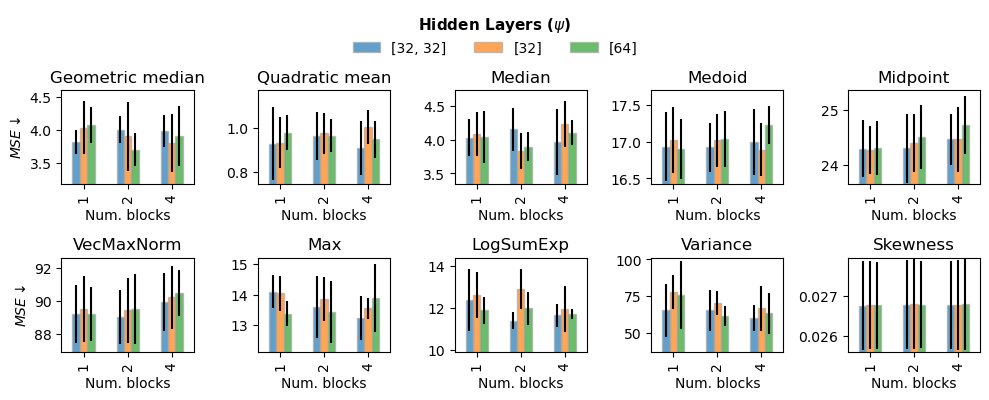

In [24]:
fig, axes = plt.subplots(2, 5, figsize = (10, 3.5))
for i, func in enumerate(funcs):
    means = test_loss_table['Mean'][func].reset_index().pivot(index='Num. blocks', columns='Hidden layers', values=func)
    stds = test_loss_table['Std'][func].reset_index().pivot(index='Num. blocks', columns='Hidden layers', values=func)
    axes[i // 5, i % 5].set_title(func)
    axes[i // 5, i % 5].set_ylim([means.min().min() -stds.max().max(), means.max().max() + stds.max().max()])
    means.plot.bar(ax = axes[i // 5, i % 5], yerr=stds, edgecolor = 'darkgrey', alpha = 0.7)

for ax in axes[:, 0]:
    ax.set_ylabel(r'$MSE \downarrow$')

handles, labels = axes[0, 0].get_legend_handles_labels()

# Remove individual legends
for ax in axes.flat:
    ax.legend().remove()

# Add a single legend at the bottom center
fig.legend(
    handles,
    labels,
    loc='upper center',
    ncol=len(labels),  # one column per legend entry
    frameon=False,
    bbox_to_anchor=(0.5, 1.15),
    title=r'Hidden Layers ($\psi$)',
    title_fontproperties={'weight': 'bold', 'size': 11}    
)

plt.tight_layout()
plt.savefig('./results/synthetic_experiment_2.png', dpi = 500, bbox_inches='tight')
plt.show()

---

<br>

## Process results from MNIST data experiment

<br>

### Process results from MNIST data experiment - Part 1

In [25]:
RES_PATH = './results/MNIST_experiment/'
NUM_REPLICATES = 4

In [26]:
MNIST_experiment_results = []
for i in range(NUM_REPLICATES):
    fn =  os.path.join(RES_PATH, 'replicate_{}.csv'.format(i))
    r = pd.read_csv(fn, index_col = 0)
    r.insert(0, 'Replicate', i)
    MNIST_experiment_results.append(r)

MNIST_experiment_results = pd.concat(MNIST_experiment_results, axis = 0)

In [27]:
model_map = {
    'MeanSet' : 'NormDeepSet', 
    'QUANN' : 'QUANN-1', 
    'QUANNTransformer' : 'QUANN-2',     
}

funcs_map = {
    'geometric_mean' : 'Geometric mean', 
    'log_mean_exp' : 'LogMeanExp',
}

test_loss_table = (
    MNIST_experiment_results
    .groupby(['Model', 'Agg func', 'Learning rate', 'Parameters'])[['Eval loss','Test loss']]
    .agg(
        {
            'Eval loss': ['mean', 'std'],
            'Test loss': ['mean', 'std']
        }
    )
    .pipe(lambda df_: df_.set_axis(['Eval mean', 'Eval std', 'Test mean', 'Test std'], axis=1))
    .reset_index()
    .sort_values('Eval mean')
    .drop_duplicates(subset = ['Model', 'Agg func'])
    .rename(columns = {'Test mean' : 'Mean', 'Test std' : 'Std'})
    .replace({
        'Model' : model_map,
        'Agg func' : funcs_map
    })
)

In [28]:
# Pivot the table
test_loss_table = test_loss_table.pivot(index='Agg func', columns="Model", values=['Mean', 'Std']).swaplevel(axis=1).sort_index(axis=1) #.loc[funcs,models]

# Remove column/index names
test_loss_table.columns.names = [None, None]
test_loss_table.index.name = None

In [29]:
main = ['max', 'mean', 'mode', 'sum', 'variance']
supp = ['Geometric mean', 'LogMeanExp', 'harmonic', 'median', 'midrange']
results_summary['MNIST-1'] = test_loss_table.loc[main,:]
results_summary['MNIST-additional'] = test_loss_table.loc[supp,:]

In [30]:
# Highlihgt significant values
test_loss_table = pd.concat({
    k : highlight_significant_latex(test_loss_table[models], maximize=False)    
    for k, models in MODELS.items()
}, axis = 1)
    
# Reduce decimals to three
test_loss_table = round_latex_numbers(test_loss_table)

In [31]:
main = ['max', 'mean', 'mode', 'sum', 'variance']
supp = ['Geometric mean', 'LogMeanExp', 'harmonic', 'median', 'midrange']

test_loss_table_main = test_loss_table.loc[main,:]
test_loss_table_supp = test_loss_table.loc[supp,:]

In [32]:
latex_table = test_loss_table_main.to_latex(
    multicolumn=True,
    multicolumn_format='c',
    multirow=True,
    bold_rows=False,
    column_format='l' + 'r' * (test_loss_table.shape[1]),  # left align first column
    escape=False,  # so that \textbf{} is preserved
)

# Boldify column headers
latex_table = re.sub(r'\\multicolumn\{2\}\{[clr]\}\{(.*?)\}', r'\\multicolumn{2}{c}{\\textbf{\1}}', latex_table)
latex_table = re.sub(r'\\multicolumn\{10\}\{[clr]\}\{(.*?)\}', r'\\multicolumn{10}{c}{\\textbf{\1}}', latex_table)
latex_table = re.sub(r'\\multicolumn\{4\}\{[clr]\}\{(.*?)\}', r'\\multicolumn{4}{c}{\\textbf{\1}}', latex_table)

# Add cmidrules
lines = latex_table.splitlines()
lines.insert(4, '\cmidrule(r){2-3} \cmidrule(r){4-5} \cmidrule(r){6-7} \cmidrule(r){8-9} \cmidrule(r){10-11} \cmidrule(r){12-13} \cmidrule(r){14-15}')
lines.insert(3, '\cmidrule(r){2-11} \cmidrule(r){12-15}')
# lines.insert(2, ' & \multicolumn{10}{c}{\textbf{Unary}} & \multicolumn{4}{c}{\textbf{Binary}} \\')
latex_table = '\n'.join(lines)

In [33]:
with open('./results/MNIST_experiment.tex', 'w') as f:
    f.write(latex_table)

In [34]:
latex_table = test_loss_table_supp.to_latex(
    multicolumn=True,
    multicolumn_format='c',
    multirow=True,
    bold_rows=False,
    column_format='l' + 'r' * (test_loss_table.shape[1]),  # left align first column
    escape=False,  # so that \textbf{} is preserved
)

# Boldify column headers
latex_table = re.sub(r'\\multicolumn\{2\}\{[clr]\}\{(.*?)\}', r'\\multicolumn{2}{c}{\\textbf{\1}}', latex_table)
latex_table = re.sub(r'\\multicolumn\{10\}\{[clr]\}\{(.*?)\}', r'\\multicolumn{10}{c}{\\textbf{\1}}', latex_table)
latex_table = re.sub(r'\\multicolumn\{4\}\{[clr]\}\{(.*?)\}', r'\\multicolumn{4}{c}{\\textbf{\1}}', latex_table)

# Add cmidrules
lines = latex_table.splitlines()
lines.insert(4, '\cmidrule(r){2-3} \cmidrule(r){4-5} \cmidrule(r){6-7} \cmidrule(r){8-9} \cmidrule(r){10-11} \cmidrule(r){12-13} \cmidrule(r){14-15}')
lines.insert(3, '\cmidrule(r){2-11} \cmidrule(r){12-15}')
# lines.insert(2, ' & \multicolumn{10}{c}{\textbf{Unary}} & \multicolumn{4}{c}{\textbf{Binary}} \\')
latex_table = '\n'.join(lines)

In [35]:
with open('./results/MNIST_experiment_supp.tex', 'w') as f:
    f.write(latex_table)

<br>

### Process results from MNIST data experiment - Part 2

In [36]:
NUM_REPLICATES = 4
RES_PATH = './results/MNIST_experiment_2/'

In [37]:
MNIST_experiment_2_results = []
for i in range(NUM_REPLICATES):
    fn =  os.path.join(RES_PATH, 'replicate_{}.csv'.format(i))
    r = pd.read_csv(fn, index_col = 0)
    r.insert(0, 'Replicate', i)
    MNIST_experiment_2_results.append(r)

MNIST_experiment_2_results = pd.concat(MNIST_experiment_2_results, axis = 0)

In [38]:
model_map = {
    'MeanSet' : 'NormDeepSet', 
    'QUANN' : 'QUANN-1', 
    'QUANNTransformer' : 'QUANN-2',     
}

test_loss_table = (
    MNIST_experiment_2_results
    .groupby(['Model', 'Agg func', 'Learning rate', 'Parameters'])[['Eval loss','Test loss']]
    .agg(
        {
            'Eval loss': ['mean', 'std'],
            'Test loss': ['mean', 'std']
        }
    )
    .pipe(lambda df_: df_.set_axis(['Eval mean', 'Eval std', 'Test mean', 'Test std'], axis=1))
    .reset_index()
    .sort_values('Eval mean')
    .drop_duplicates(subset = ['Model', 'Agg func'])
    .rename(columns = {'Test mean' : 'Mean', 'Test std' : 'Std'})
    .replace({
        'Model' : model_map,
        'Agg func' : funcs_map
    })
)

In [39]:
# Pivot the table
test_loss_table = test_loss_table.pivot(index='Agg func', columns="Model", values=['Mean', 'Std']).swaplevel(axis=1).sort_index(axis=1)

# Remove column/index names
test_loss_table.columns.names = [None, None]
test_loss_table.index.name = None

In [40]:
results_summary['MNIST-2'] = test_loss_table

In [41]:
# Highlihgt significant values
test_loss_table = pd.concat({
    k : highlight_significant_latex(test_loss_table[models], maximize=False)    
    for k, models in MODELS.items()
}, axis = 1)
    
# Reduce decimals to three
test_loss_table = round_latex_numbers(test_loss_table)

In [42]:
latex_table = test_loss_table_main.to_latex(
    multicolumn=True,
    multicolumn_format='c',
    multirow=True,
    bold_rows=False,
    column_format='l' + 'r' * (test_loss_table.shape[1]),  # left align first column
    escape=False,  # so that \textbf{} is preserved
)

# Boldify column headers
latex_table = re.sub(r'\\multicolumn\{2\}\{[clr]\}\{(.*?)\}', r'\\multicolumn{2}{c}{\\textbf{\1}}', latex_table)
latex_table = re.sub(r'\\multicolumn\{10\}\{[clr]\}\{(.*?)\}', r'\\multicolumn{10}{c}{\\textbf{\1}}', latex_table)
latex_table = re.sub(r'\\multicolumn\{4\}\{[clr]\}\{(.*?)\}', r'\\multicolumn{4}{c}{\\textbf{\1}}', latex_table)

# Add cmidrules
lines = latex_table.splitlines()
lines.insert(4, '\cmidrule(r){2-3} \cmidrule(r){4-5} \cmidrule(r){6-7} \cmidrule(r){8-9} \cmidrule(r){10-11} \cmidrule(r){12-13} \cmidrule(r){14-15}')
lines.insert(3, '\cmidrule(r){2-11} \cmidrule(r){12-15}')
# lines.insert(2, ' & \multicolumn{10}{c}{\textbf{Unary}} & \multicolumn{4}{c}{\textbf{Binary}} \\')
latex_table = '\n'.join(lines)

In [43]:
with open('./results/MNIST_experiment_2.tex', 'w') as f:
    f.write(latex_table)

<br>

## Process results from Omniglot data experiment

In [44]:
NUM_REPLICATES = 4
RES_PATH = './results/Omniglot_experiment/'

In [45]:
Omniglot_experiment_results = []
for i in range(NUM_REPLICATES):
    fn =  os.path.join(RES_PATH, 'replicate_{}.csv'.format(i))
    r = pd.read_csv(fn, index_col = 0)
    r.insert(0, 'Replicate', i)
    Omniglot_experiment_results.append(r)

Omniglot_experiment_results = pd.concat(Omniglot_experiment_results, axis = 0)

In [46]:
model_map = {
    'MeanSet' : 'NormDeepSet', 
    'QUANN' : 'QUANN-1', 
    'QUANNTransformer' : 'QUANN-2', 
}


test_loss_table = (
    Omniglot_experiment_results
    .groupby(['Model', 'Max_k', 'Learning rate', 'Parameters'])[['Eval loss','Test perf']]
    .agg(
        {
            'Eval loss': ['mean', 'std'],
            'Test perf': ['mean', 'std']
        }
    )
    .pipe(lambda df_: df_.set_axis(['Eval mean', 'Eval std', 'Test mean', 'Test std'], axis=1))
    .reset_index()
    .sort_values('Eval mean', ascending = True)
    .drop_duplicates(subset = ['Model', 'Max_k'])
    .rename(columns = {'Test mean' : 'Mean', 'Test std' : 'Std'})
    .replace({
        'Model' : model_map,
        # 'Agg func' : funcs_map
    })
)

In [47]:
# Pivot the table
test_loss_table = test_loss_table.pivot(index='Max_k', columns="Model", values=['Mean', 'Std']).swaplevel(axis=1).sort_index(axis=1) #.loc[funcs,models]

# Remove column/index names
test_loss_table.columns.names = [None, None]
test_loss_table.index.name = None

In [48]:
results_summary['Omniglot'] = test_loss_table

In [49]:
# Highlihgt significant values
test_loss_table = pd.concat({
    k : highlight_significant_latex(test_loss_table[models], maximize=True)    
    for k, models in MODELS.items()
}, axis = 1)
    
# Reduce decimals to three
test_loss_table = round_latex_numbers(test_loss_table)

In [50]:
latex_table = test_loss_table.to_latex(
    multicolumn=True,
    multicolumn_format='c',
    multirow=True,
    bold_rows=False,
    column_format='l' + 'r' * (test_loss_table.shape[1]),  # left align first column
    escape=False,  # so that \textbf{} is preserved
)

# Boldify column headers
latex_table = re.sub(r'\\multicolumn\{2\}\{[clr]\}\{(.*?)\}', r'\\multicolumn{2}{c}{\\textbf{\1}}', latex_table)
latex_table = re.sub(r'\\multicolumn\{10\}\{[clr]\}\{(.*?)\}', r'\\multicolumn{10}{c}{\\textbf{\1}}', latex_table)
latex_table = re.sub(r'\\multicolumn\{4\}\{[clr]\}\{(.*?)\}', r'\\multicolumn{4}{c}{\\textbf{\1}}', latex_table)

# Add cmidrules
lines = latex_table.splitlines()
lines.insert(4, '\cmidrule(r){2-3} \cmidrule(r){4-5} \cmidrule(r){6-7} \cmidrule(r){8-9} \cmidrule(r){10-11} \cmidrule(r){12-13} \cmidrule(r){14-15}')
lines.insert(3, '\cmidrule(r){2-11} \cmidrule(r){12-15}')
# lines.insert(2, ' & \multicolumn{10}{c}{\textbf{Unary}} & \multicolumn{4}{c}{\textbf{Binary}} \\')
latex_table = '\n'.join(lines)

In [51]:
with open('./results/Omniglot_experiment.tex', 'w') as f:
    f.write(latex_table)

<br>

### Omniglot image classification accuracy

In [52]:
model_map = {
    'MeanSet' : 'NormDeepSet', 
    'QUANN' : 'QUANN-1', 
    'QUANNTransformer' : 'QUANN-2', 
}

test_loss_table = (
    Omniglot_experiment_results
    .groupby(['Model', 'Max_k', 'Learning rate', 'Parameters'])[['Img Classif Loss', 'Img Classif Perf']]
    .agg(
        {
            'Img Classif Loss': ['mean', 'std'],
            'Img Classif Perf': ['mean', 'std']
        }
    )
    .pipe(lambda df_: df_.set_axis(['Eval mean', 'Eval std', 'Test mean', 'Test std'], axis=1))
    .reset_index()
    .sort_values('Eval mean', ascending = True)
    .drop_duplicates(subset = ['Model', 'Max_k'])
    .rename(columns = {'Test mean' : 'Mean', 'Test std' : 'Std'})
    .replace({
        'Model' : model_map,
        # 'Agg func' : funcs_map
    })
)

In [53]:
test_loss_table = test_loss_table.sort_values(['Mean'], ascending = False).drop_duplicates(subset = 'Model').set_index("Model")[["Mean", "Std"]]

In [54]:
# Highlihgt significant values
test_loss_table = pd.concat({
    k : test_loss_table.loc[models,:]    
    for k, models in MODELS.items()
}, axis = 0)
    
# Reduce decimals to three
test_loss_table = round_latex_numbers(test_loss_table)

# Drop index names
test_loss_table.index.names = [None, None]

In [55]:
value = test_loss_table.loc[('Unary', 'QUANN-1'), 'Mean']
test_loss_table.loc[('Unary', 'QUANN-1'), 'Mean'] = f"\\textbf{{{value}}}"

In [56]:
value = test_loss_table.loc[('Binary', 'QUANN-2'), 'Mean']
test_loss_table.loc[('Binary', 'QUANN-2'), 'Mean'] = f"\\textbf{{{value}}}"

In [57]:
latex_table = test_loss_table.to_latex(
    multicolumn=True,
    multicolumn_format='c',
    multirow=True,
    bold_rows=False,
    column_format='ll' + 'c' * (test_loss_table.shape[1]),  # left align first column
    escape=False,  # so that \textbf{} is preserved
)

latex_table = re.sub(r'\\cline{1-4}', r'\\vspace{2\\baselineskip}\\\\', latex_table)

lines = latex_table.splitlines()
lines.insert(2, r'& & \multicolumn{2}{c}{ACC $\uparrow$} \\')
lines.insert(3, r' \cmidrule(r){3-4}')
del(lines[-3])
latex_table = '\n'.join(lines)

In [58]:
with open('./results/Omniglot_transfer_learning.tex', 'w') as f:
    f.write(latex_table)

<br>

## Process results from ModelNet data experiment


In [59]:
NUM_REPLICATES = 4
RES_PATH = './results/ModelNet_experiment/'

In [60]:
ModelNet_experiment_results = []
for i in range(NUM_REPLICATES):
    fn =  os.path.join(RES_PATH, 'replicate_{}.csv'.format(i))
    r = pd.read_csv(fn, index_col = 0)
    r.insert(0, 'Replicate', i)
    ModelNet_experiment_results.append(r)

ModelNet_experiment_results = pd.concat(ModelNet_experiment_results, axis = 0)

In [61]:
model_map = {
    'MeanSet' : 'NormDeepSet', 
    'QUANN' : 'QUANN-1', 
    'QUANNTransformer' : 'QUANN-2', 
}


test_loss_table = (
    ModelNet_experiment_results
    .groupby(['Model', 'Min_K', 'Learning rate', 'Parameters'])[['Eval loss','Test perf']]
    .agg(
        {
            'Eval loss': ['mean', 'std'],
            'Test perf': ['mean', 'std']
        }
    )
    .pipe(lambda df_: df_.set_axis(['Eval mean', 'Eval std', 'Test mean', 'Test std'], axis=1))
    .reset_index()
    .sort_values('Eval mean', ascending = True)
    .drop_duplicates(subset = ['Model', 'Min_K'])
    .rename(columns = {'Test mean' : 'Mean', 'Test std' : 'Std'})
    .replace({
        'Model' : model_map,
        # 'Agg func' : funcs_map
    })
)

In [62]:
# Pivot the table
test_loss_table = test_loss_table.pivot(index='Min_K', columns="Model", values=['Mean', 'Std']).swaplevel(axis=1).sort_index(axis=1) #.loc[funcs,models]

# Remove column/index names
test_loss_table.columns.names = [None, None]
test_loss_table.index.name = None

In [63]:
results_summary['ModelNet40'] = test_loss_table

In [64]:
# Highlihgt significant values
test_loss_table = pd.concat({
    k : highlight_significant_latex(test_loss_table[models], maximize=True)    
    for k, models in MODELS.items()
}, axis = 1)
    
# Reduce decimals to three
test_loss_table = round_latex_numbers(test_loss_table)

In [65]:
latex_table = test_loss_table.to_latex(
    multicolumn=True,
    multicolumn_format='c',
    multirow=True,
    bold_rows=False,
    column_format='l' + 'r' * (test_loss_table.shape[1]),  # left align first column
    escape=False,  # so that \textbf{} is preserved
)

# Boldify column headers
latex_table = re.sub(r'\\multicolumn\{2\}\{[clr]\}\{(.*?)\}', r'\\multicolumn{2}{c}{\\textbf{\1}}', latex_table)
latex_table = re.sub(r'\\multicolumn\{10\}\{[clr]\}\{(.*?)\}', r'\\multicolumn{10}{c}{\\textbf{\1}}', latex_table)
latex_table = re.sub(r'\\multicolumn\{4\}\{[clr]\}\{(.*?)\}', r'\\multicolumn{4}{c}{\\textbf{\1}}', latex_table)

# Add cmidrules
lines = latex_table.splitlines()
lines.insert(4, '\cmidrule(r){2-3} \cmidrule(r){4-5} \cmidrule(r){6-7} \cmidrule(r){8-9} \cmidrule(r){10-11} \cmidrule(r){12-13} \cmidrule(r){14-15}')
lines.insert(3, '\cmidrule(r){2-11} \cmidrule(r){12-15}')
# lines.insert(2, ' & \multicolumn{10}{c}{\textbf{Unary}} & \multicolumn{4}{c}{\textbf{Binary}} \\')
latex_table = '\n'.join(lines)

In [66]:
with open('./results/ModelNet40_experiment.tex', 'w') as f:
    f.write(latex_table)

<br>

### Compare MNIST 1 and 2 results

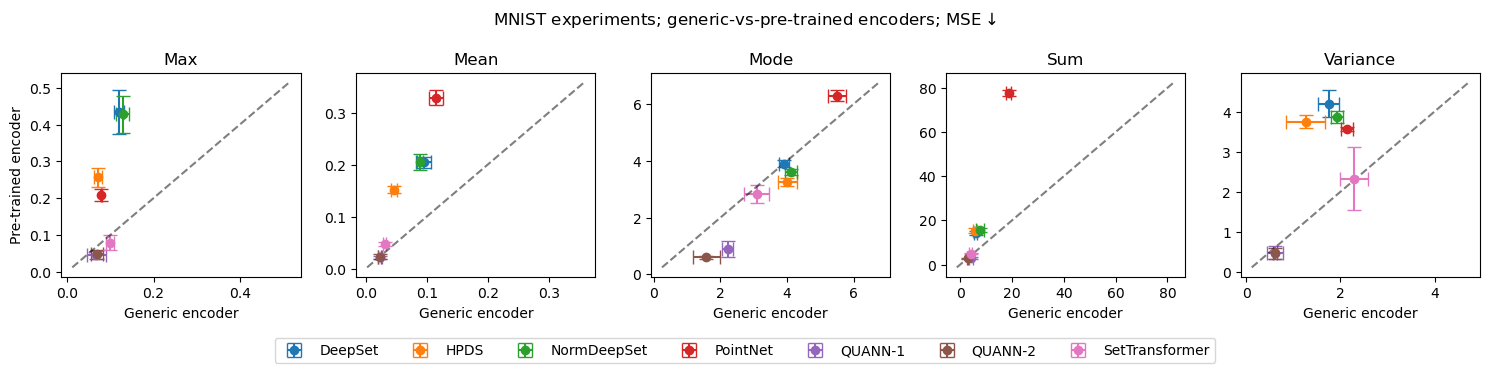

In [67]:
# List of models
models = ['DeepSet', 'HPDS', 'NormDeepSet', 'PointNet', 'QUANN-1', 'QUANN-2', 'SetTransformer']

# List of indices
set_functions = ['max', 'mean', 'mode', 'sum', 'variance']

# Set up figure and axes (no shared x or y)
fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))

# Loop through each set function
for idx, (ax, set_func) in enumerate(zip(axes, set_functions)):
    # For each model, plot the point with error bars
    for model in models:
        mean_1 = results_summary['MNIST-1'].loc[set_func, (model, 'Mean')]
        std_1 = results_summary['MNIST-1'].loc[set_func, (model, 'Std')]
        mean_2 = results_summary['MNIST-2'].loc[set_func, (model, 'Mean')]
        std_2 = results_summary['MNIST-2'].loc[set_func, (model, 'Std')]
        
        ax.errorbar(mean_1, mean_2, xerr=std_1, yerr=std_2, fmt='o', label=model, capsize=5)
    
    # Identity line
    min_lim = min(ax.get_xlim()[0], ax.get_ylim()[0])
    max_lim = max(ax.get_xlim()[1], ax.get_ylim()[1])
    ax.plot([min_lim, max_lim], [min_lim, max_lim], 'k--', alpha=0.5)

    # Titles and labels
    ax.set_title(set_func.capitalize())
    ax.set_xlabel('Generic encoder')
    
    if idx == 0:
        ax.set_ylabel('Pre-trained encoder')
    
    # ax.grid(True)

# Overall figure title
fig.suptitle(r'MNIST experiments; generic-vs-pre-trained encoders; MSE$\downarrow$', fontsize=12)

# Legend (only once, outside)
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol = 7)

plt.tight_layout(rect=[0.0, 0.05, 1, 1.0])  # leave space for suptitle
plt.savefig('./results/MNIST_generic_vs_pretrained.png', bbox_inches='tight', dpi = 500)
plt.show()


<br>

### Single performance table

In [68]:
results_summary['Omniglot'].index = [f"$n_{{\\text{{max}}}} = {i}$" for i in results_summary['Omniglot'].index]

In [69]:
results_summary['ModelNet40'].index = [f"$n_{{\\text{{min}}}} = {i}$" for i in results_summary['ModelNet40'].index]

In [70]:
orient = {
    'MNIST-1' : False,
    'MNIST-2' : False,
    'Omniglot' : True,
    'ModelNet40' : True   
}

tables = {}
for experiment, result in results_summary.items():
    if experiment != 'MNIST-additional':
        # Highlihgt significant values
        table = pd.concat({
            k : highlight_significant_latex(result[models], maximize=orient[experiment])    
            for k, models in MODELS.items()
        }, axis = 1)
            
        # Reduce decimals to three
        tables[experiment] = round_latex_numbers(table)    

tables = pd.concat(list(tables.values()))

In [71]:
latex_table = tables.to_latex(
    multicolumn=True,
    multicolumn_format='c',
    multirow=True,
    bold_rows=False,
    column_format='l' + 'r' * (tables.shape[1]),  # left align first column
    escape=False,  # so that \textbf{} is preserved
)

# Boldify column headers
latex_table = re.sub(r'QUANN-1', r'\\textbf{QUANN-1}', latex_table)
latex_table = re.sub(r'QUANN-2', r'\\textbf{QUANN-2}', latex_table)

# Add cmidrules
lines = latex_table.splitlines()
lines.insert(4, '\cmidrule(r){2-3} \cmidrule(r){4-5} \cmidrule(r){6-7} \cmidrule(r){8-9} \cmidrule(r){10-11} \cmidrule(r){12-13} \cmidrule(r){14-15}')
lines.insert(3, '\cmidrule(r){2-11} \cmidrule(r){12-15}')
latex_table = '\n'.join(lines)

# Add experiment separators
lines = latex_table.splitlines()
lines.insert(8, r'\multicolumn{15}{c}{\textit{MNIST, MSE $\downarrow$}} \\')
lines.insert(9, '\midrule')
lines.insert(15, '\midrule')
lines.insert(16, r'\multicolumn{15}{c}{\textit{MNIST - Pre-trained encoders, MSE $\downarrow$}} \\')
lines.insert(17, '\midrule')
lines.insert(23, '\midrule')
lines.insert(24, r'\multicolumn{15}{c}{\textit{Omniglot, Balanced ACC $\uparrow$}} \\')
lines.insert(25, '\midrule')
lines.insert(30, '\midrule')
lines.insert(31, r'\multicolumn{15}{c}{\textit{ModelNet40, ACC $\uparrow$}} \\')
lines.insert(32, '\midrule')
latex_table = '\n'.join(lines)

In [72]:
with open('./results/performance_table.tex', 'w') as f:
    f.write(latex_table)

<br>

## Win-loss matrices

In [73]:
models = ['DeepSet', 'PointNet', 'NormDeepSet', 'HPDS', 'SetTransformer', 'QUANN-1', 'QUANN-2']
wlmat = np.zeros((len(models), len(models)))

orient = {
    'MNIST-1' : -1,
    'MNIST-2' : -1,
    'Omniglot' : 1,
    'ModelNet40' : 1    
}

N = 0
for k, r in results_summary.items():
    if k != 'MNIST-additional':
        for i, m1 in enumerate(models):
            for j, m2 in enumerate(models):
                if m1 == m2:
                    wlmat[i, j] = np.nan
                else:
                    wlmat[i, j] += (orient[k] * r[(m1, 'Mean')] > orient[k] * r[(m2, 'Mean')]).sum()                
        N += r.shape[0]

In [74]:
pvmat = np.ones_like(wlmat)
for i, m1 in enumerate(models):
    for j, m2 in enumerate(models):
        if m1 == m2:
            pvmat[i, j] = np.nan
        else:
            k = int(wlmat[i, j])
            pvmat[i, j] = binomtest(k = k, n = N, p = 0.5, alternative='greater').pvalue

In [75]:
wlmat /= N

In [76]:
wlmat = pd.DataFrame(wlmat, index = models, columns = models)
pvmat = pd.DataFrame(pvmat, index = models, columns = models)

<Figure size 640x480 with 0 Axes>

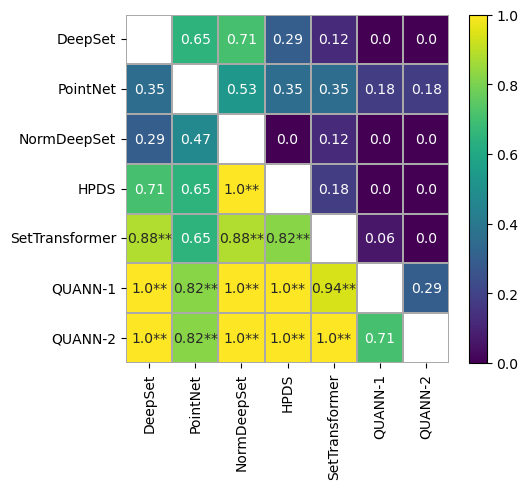

In [77]:
plt.clf()

fig = plt.figure(
    layout="tight", 
    figsize = (5.5, 5.00)
)

annot = wlmat.round(2).astype('str')
annot[pvmat < 0.05] += '*'
annot[pvmat < 0.01] += '*'

ax = sns.heatmap(
    # -np.log(pvmat),
    # pvmat,
    wlmat,
    annot = annot.values,
    fmt = '',
    # fmt='.2f',
    # ax = axes[i],
    vmin = 0.,
    vmax = 1.,
    cbar = False,
    cmap = 'viridis',
    linewidths=.25, 
    linecolor='darkgrey',
)

fig.colorbar(
    ax.collections[0], 
    # cax=cbax,
    orientation = 'vertical',
    # label=''
)

plt.savefig('./results/winloss_heatmap.png', dpi = 400)
plt.show()

<br>

### Table with number of model parameters

In [78]:
results = {
    'Synthetic' : synthetic_experiment_results,
    'MNIST' : MNIST_experiment_results,
    'MNIST-pretrained' : MNIST_experiment_2_results,
    'Omniglot' : Omniglot_experiment_results,
    'ModelNet40' : ModelNet_experiment_results,
}

models = ['Ablation 1', 'Ablation 2', 'DeepSet', 'NormDeepSet', 'HPDS', 'QUANN-1', 'SetTransformer', 'QUANN-2']

param_table = {}
for name, res in results.items():
    param_table[name]= (
        res[['Model', 'Parameters']]
        .replace({'Model' : {'Ablation_1' : 'Ablation 1', 'Ablation_2' : 'Ablation 2', 'QUANN_1' : 'QUANN-1', 'QUANN' : 'QUANN-1', 'QUANNTransformer' : 'QUANN-2', 'MeanSet' : 'NormDeepSet'}})
        .drop_duplicates()
        .set_index('Model')
        .loc[:,'Parameters']
    )

param_table = (
    pd
    .concat(param_table, axis = 1)
    .loc[models,:]
    .apply(pd.to_numeric, errors='coerce')
    .astype('Int64') 
)

In [79]:
param_table.index.name = None

In [80]:
params_table_latex = param_table.to_latex(na_rep='')
params_table_latex = params_table_latex.replace('QUANN-1', r'\textbf{QUANN-1}')
params_table_latex = params_table_latex.replace('QUANN-2', r'\textbf{QUANN-2}')

In [81]:
with open('./results/params_table.tex', 'w') as f:
    f.write(params_table_latex)

---